In [1]:
from qiskit import __version__
print(__version__)

2.4.1


# Importing Packages

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, state_fidelity, Pauli, DensityMatrix, partial_trace
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_aer.library import SaveDensityMatrix, SaveStatevector, SetDensityMatrix
from qiskit import transpile 
import numpy as np
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.circuit.library import HGate, UnitaryGate, IGate
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter
from matplotlib.gridspec import GridSpec
from scipy.optimize import curve_fit

# Defining Global Variable

In [3]:
x_star = 1/3 * (-2 + np.cbrt(19-3*np.sqrt(33)) + np.cbrt(19+3*np.sqrt(33)))
z_star = np.sqrt(1 - x_star**2)
theta = np.arcsin(x_star)

# Graphing Settings

In [4]:
mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 8,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.2,
    'figure.dpi': 150,
})

# Defining Numpy Matrices

In [5]:
identity = np.array([[1,0], [0,1]])
ry_theta = np.array([[np.cos(theta/2), -np.sin(theta/2)], [np.sin(theta/2), np.cos(theta/2)]])

# Infidelity to Error Rates

In [6]:
def inf_to_error(infidelity_list, num_qubits):
    error_rates_list = []
    dimension = 2**num_qubits
    for infidelity in infidelity_list:
        error_rates_list.append( infidelity * (dimension / (dimension - 1)) )
    
    return error_rates_list

In [7]:
one_qubit_gate_infidelity = [2.8e-5 * i for i in range(1,6)]
two_qubit_gate_infidelity = [8.3e-4 * i for i in range(1,6)]
idle_gate_infidelity = [1.2e-4 * i for i in range(1,6)]
spam0 = [6.7e-4 * i for i in range(1,6)] # P(1|0), measured 1 given that 0 was prepared
spam1 = [1.2e-3 * i for i in range(1,6)] # P(0|1)

In [8]:
one_qubit_gate_error_prob = inf_to_error(one_qubit_gate_infidelity, num_qubits=1)
two_qubit_gate_error_prob = inf_to_error(two_qubit_gate_infidelity, num_qubits=2)
idle_gate_error_prob = inf_to_error(idle_gate_infidelity, num_qubits=1)

# Simulations 

Consider the case when only state preparation is noisy

In [11]:
ideal = QuantumCircuit(2)
ideal.ry(theta,0)
ideal_dm = DensityMatrix(ideal)

ideal_1q = QuantumCircuit(1)
ideal_1q.ry(theta,0)
ideal_1q_dm = DensityMatrix(ideal_1q)

In [ ]:
# Number of distillation rounds and simulation shots per round.
rounds = 50
shots = 50

# Initialize the first-round input error rate.
error_prob = one_qubit_gate_error_prob[4]

# Store the output infidelity after each round.
infidelity_list = []

# Initial single-qubit input density matrix, and adding its infidelity to the infidelity list
prep = ry_theta @ np.matmul([[1],[0]], [[1,0]]) @ ry_theta.conj().T
mixed = identity / 2
rho_in = (1 - error_prob) * prep + error_prob * mixed
rho_in = rho_in / np.trace(rho_in)
temp = DensityMatrix(rho_in)
infidelity_list.append(1 - state_fidelity(ideal_1q_dm, temp))

for r in range(rounds):
    # Building the input density matrix
    rho_two = DensityMatrix(np.kron(rho_in.data, rho_in.data))
    meas_circuit = QuantumCircuit(2, 1)
    meas_circuit.append(SetDensityMatrix(rho_two), meas_circuit.qubits)

    # Two-qubit distillation circuit
    meas_circuit.cx(0, 1)
    meas_circuit.h(0)

    # Measure out qubit 1 and postselect on 0
    meas_circuit.measure([1], [0])

    # Measure for post-selection and save the conditional density matrix.
    meas_circuit.append(
        SaveDensityMatrix(
            num_qubits=2,
            label="dm_post",
            conditional=True,
            pershot=True
        ),
        meas_circuit.qubits
    )

    # Run the density-matrix simulation.
    noise_model = NoiseModel()
    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(meas_circuit, shots=shots)
    result = job.result()
    
    # Compute the accepted output infidelity.
    res_dm = result.data()['dm_post']
    rho_post_2q = res_dm["0x0"][0]
    infidelity_list.append(1 - state_fidelity(rho_post_2q, ideal_dm))
    
    # Turn output into next round's input density matrix
    rho_out = partial_trace(rho_post_2q, [1])
    rho_in = rho_out

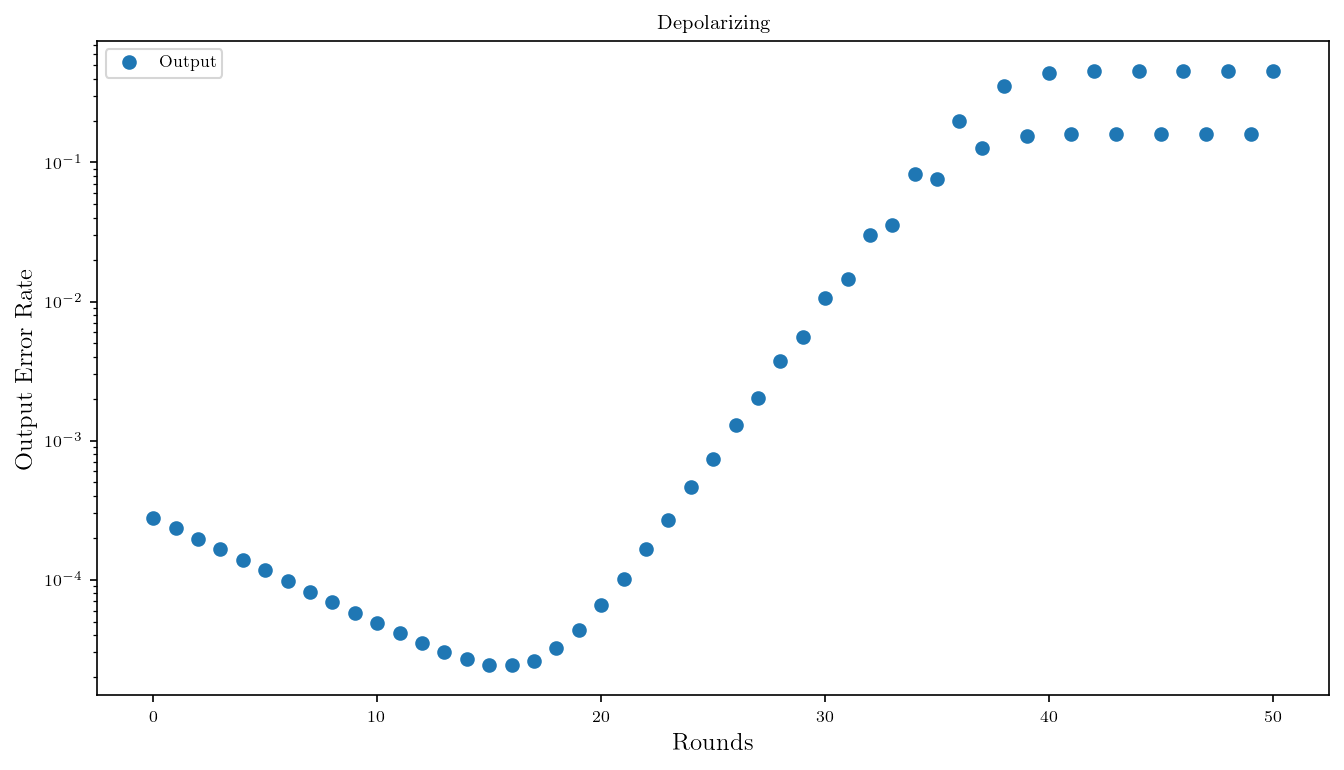

In [15]:
rounds_arr = np.array([r for r in range(rounds+1)])
output_error_rate = inf_to_error(infidelity_list, 1)

plt.figure(figsize=(9, 5))
plt.plot(rounds_arr, output_error_rate, 'o', label='Output')
plt.xlabel("Rounds", fontsize=12)
plt.ylabel("Output Error Rate", fontsize=12)
plt.yscale('log')
plt.tight_layout()
plt.legend()
plt.title("Depolarizing")
plt.show()

# Analysis

Finding the round and infidelity where the MSD protocols begins to fail

In [20]:
error_rate_threshold = 1
round_threshold = 0
for i in range(len(output_error_rate)):
    if output_error_rate[i] < error_rate_threshold:
        error_rate_threshold = output_error_rate[i]
        round_threshold = i
    else:
        break

In [21]:
print(error_rate_threshold)
print(round_threshold)

2.4190276921354226e-05
16


# Theoretical Estimate of Distillation Round Threshold

In [19]:
c10 = x_star 
d01 = z_star**2 + 1
c02 = 0.30343
p = one_qubit_gate_error_prob[4]

m = np.log( np.abs(c10-1)*(x_star+z_star) / (c02*p*(x_star-z_star)**2) ) / np.log(d01**2 / c10)
print(f"Rounds of Distillation Threshold: {m}") 

infidelity_threshold = (c10**m * p/(x_star+z_star))*(x_star+z_star) / 2
print(f"Infidelity Threshold: {infidelity_threshold}")

output_error_rate_threshold = inf_to_error([infidelity_threshold], 1)[0]
print(f"Output Error Rate Threshold: {output_error_rate_threshold}")

Rounds of Distillation Threshold: 14.869772215800442
Infidelity Threshold: 1.0344096493008673e-05
Output Error Rate Threshold: 2.0688192986017347e-05


# Saving Data

In [22]:
np.savez(
    "depolarizing_error_rates.npz",
    rounds_arr=rounds_arr,
    output_error_rate=output_error_rate,
    simulation_round_threshold=round_threshold,
    theoretical_round_threshold=m,
    simulation_output_error_rate_threshold=error_rate_threshold,
    theoretical_output_error_rate_threshold=output_error_rate_threshold
)